Dataset Loading and Initial Analysis

Dataset head:
             meantemp   humidity  wind_speed  meanpressure
date                                                      
2017-01-01  15.913043  85.869565    2.743478     59.000000
2017-01-02  18.500000  77.222222    2.894444   1018.277778
2017-01-03  17.111111  81.888889    4.016667   1018.333333
2017-01-04  18.700000  70.050000    4.545000   1015.700000
2017-01-05  18.388889  74.944444    3.300000   1014.333333


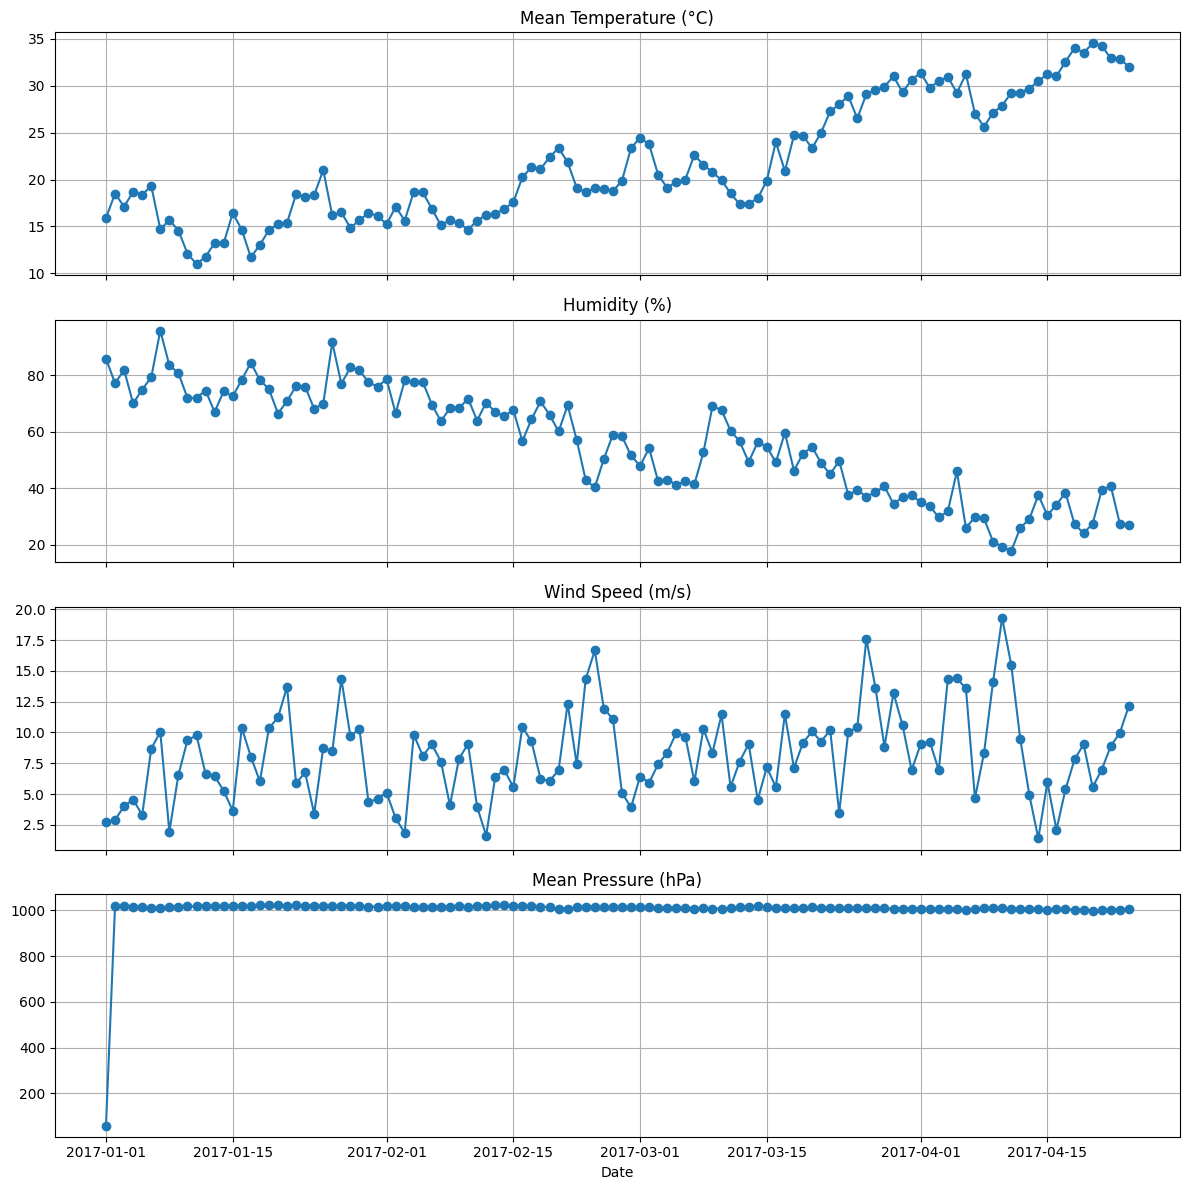

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("DailyDelhiClimateTest.csv", parse_dates=['date'], index_col='date')

print("Dataset head:")
print(df.head())

fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=True)


variables = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
titles = ["Mean Temperature (°C)", "Humidity (%)", "Wind Speed (m/s)", "Mean Pressure (hPa)"]

for i, var in enumerate(variables):
    axs[i].plot(df.index, df[var], marker='o', linestyle='-')
    axs[i].set_title(titles[i])
    axs[i].grid(True)

plt.xlabel("Date")
plt.tight_layout()
plt.show()


In [12]:
print("Overall Mean and Variance:")
for col in df.columns:
    col_mean = df[col].mean()
    col_var = df[col].var()
    print(f"{col} -> Mean: {col_mean:.2f}, Variance: {col_var:.2f}")

Overall Mean and Variance:
meantemp -> Mean: 21.71, Variance: 40.45
humidity -> Mean: 56.26, Variance: 363.59
wind_speed -> Mean: 8.14, Variance: 12.87
meanpressure -> Mean: 1004.04, Variance: 8005.72


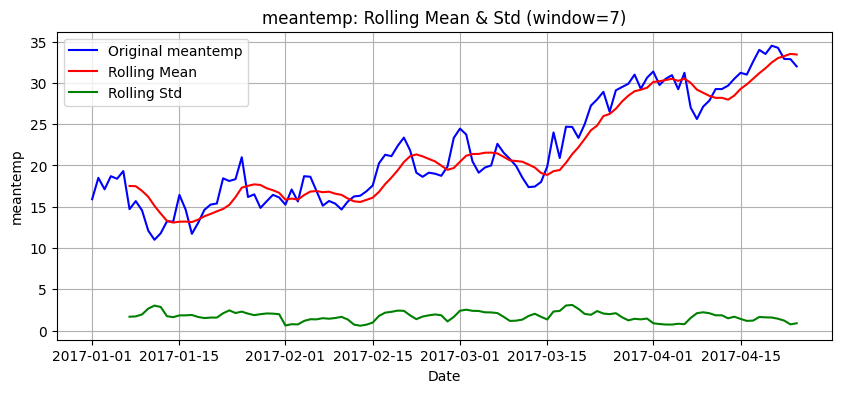

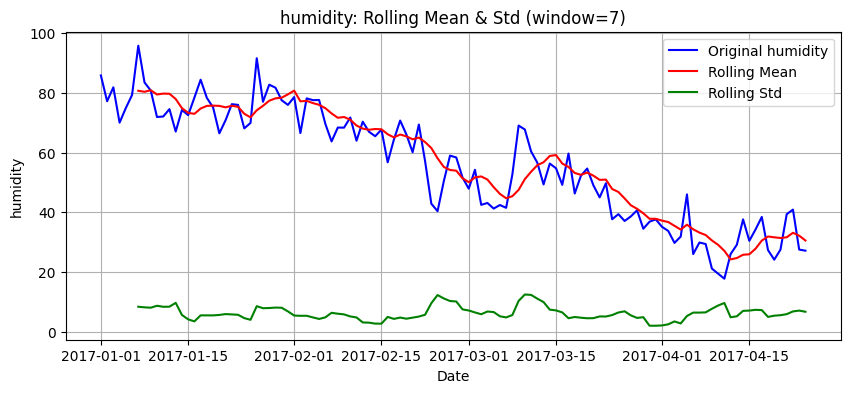

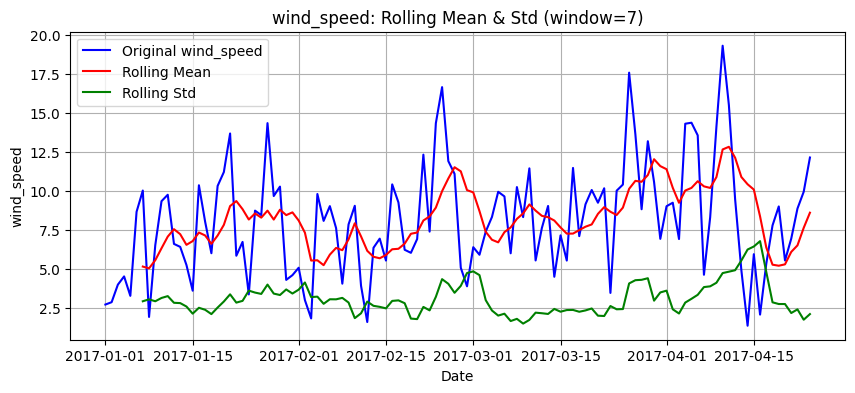

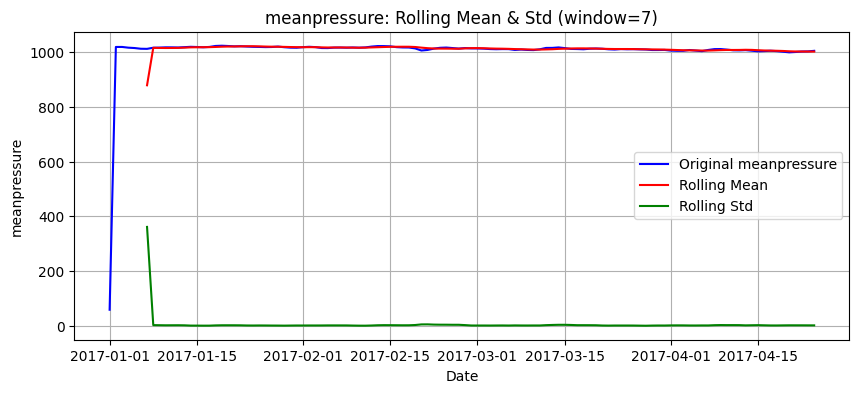

In [13]:
window_size = 7  # 7-day rolling window

for col in df.columns:
    plt.figure(figsize=(10, 4))
    rolling_mean = df[col].rolling(window=window_size).mean()
    rolling_std = df[col].rolling(window=window_size).std()

    plt.plot(df.index, df[col], label=f'Original {col}', color='blue')
    plt.plot(df.index, rolling_mean, label='Rolling Mean', color='red')
    plt.plot(df.index, rolling_std, label='Rolling Std', color='green')
    plt.title(f'{col}: Rolling Mean & Std (window={window_size})')
    plt.xlabel('Date')
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.show()

In [14]:
from statsmodels.tsa.stattools import adfuller

def adf_test(series, col_name=''):
    """Perform ADF test and print results."""
    result = adfuller(series.dropna(), autolag='AIC')
    print(f"--- ADF Test for {col_name} ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("\n")

for col in df.columns:
    adf_test(df[col], col_name=col)

--- ADF Test for meantemp ---
ADF Statistic: -1.0965
p-value: 0.7165


--- ADF Test for humidity ---
ADF Statistic: -0.6757
p-value: 0.8529


--- ADF Test for wind_speed ---
ADF Statistic: -6.5181
p-value: 0.0000


--- ADF Test for meanpressure ---
ADF Statistic: -2.1822
p-value: 0.2128




As indicated by plotting the Mean and STD, we can now conclude that the Wind Speed Time series is atationary, and the rest are non-stationary.
I feel like the Pressure would be stationary if it was not for the few outliers at the begining of the TS. 

In [ ]:
from statsmodels.stats.stattools import durbin_watson
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("Durbin-Watson Test Results:")
for col in df.columns:
    dw_stat = durbin_watson(df[col])
    print(f"{col}: {dw_stat:.4f}")

Durbin-Watson Test Results:
meantemp: 0.0055
humidity: 0.0156
wind_speed: 0.1738
meanpressure: 0.0079


Values close to 0 strongly indicate that there is very high positive autocorrelation in the dataset

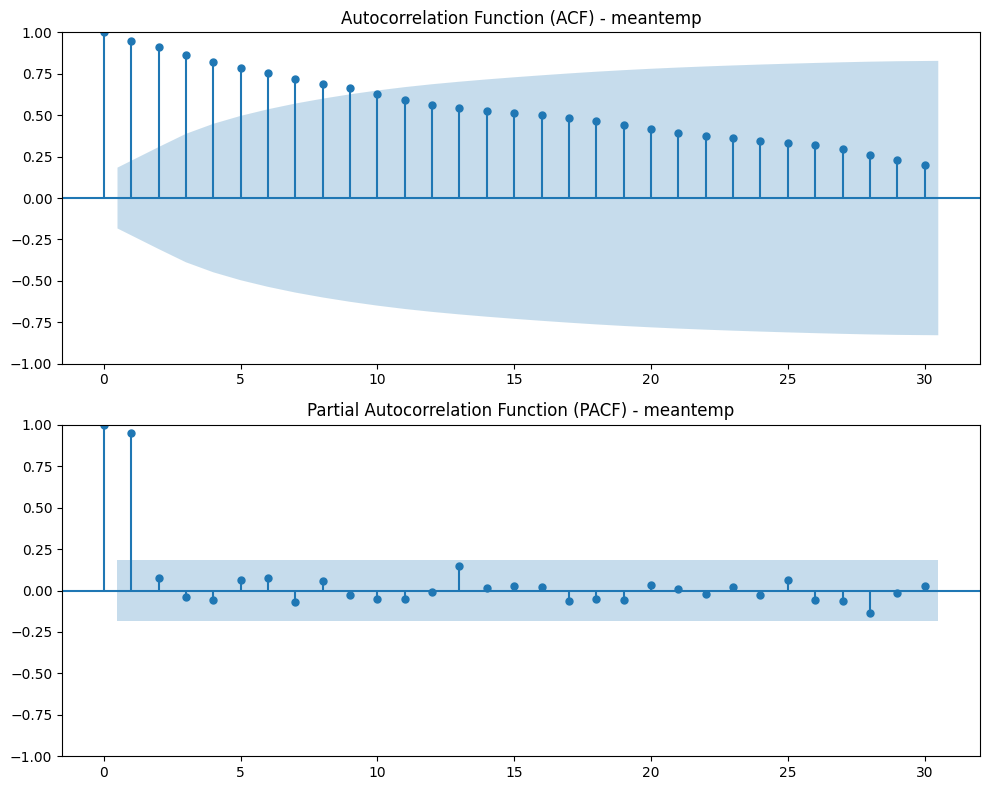

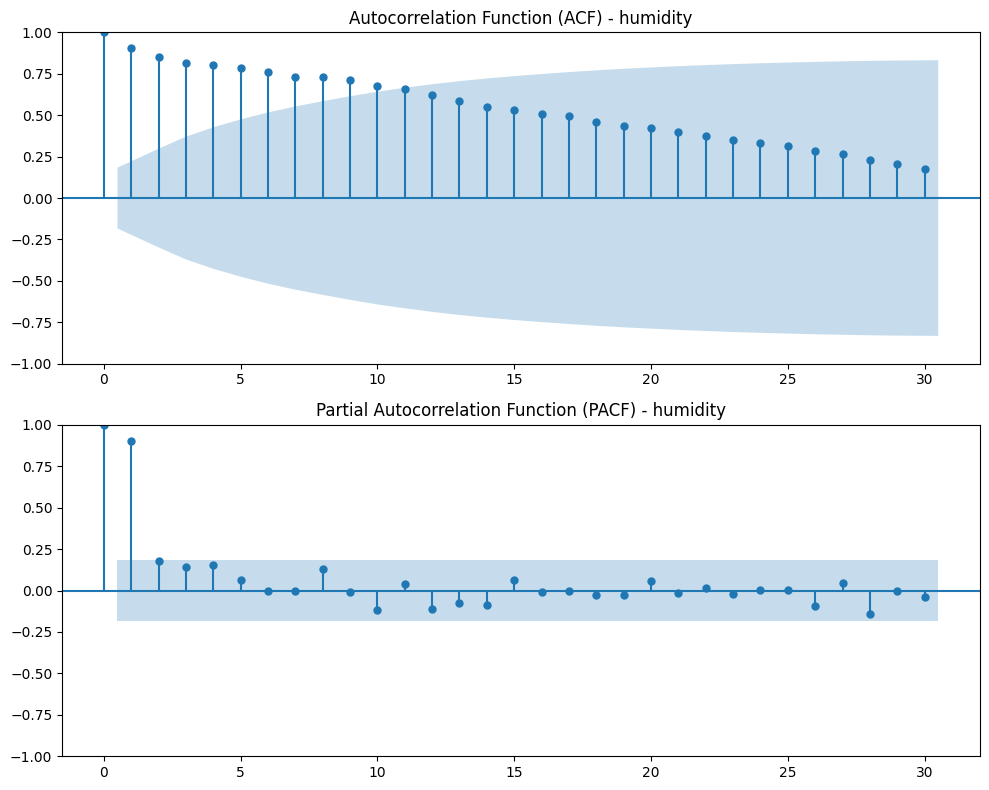

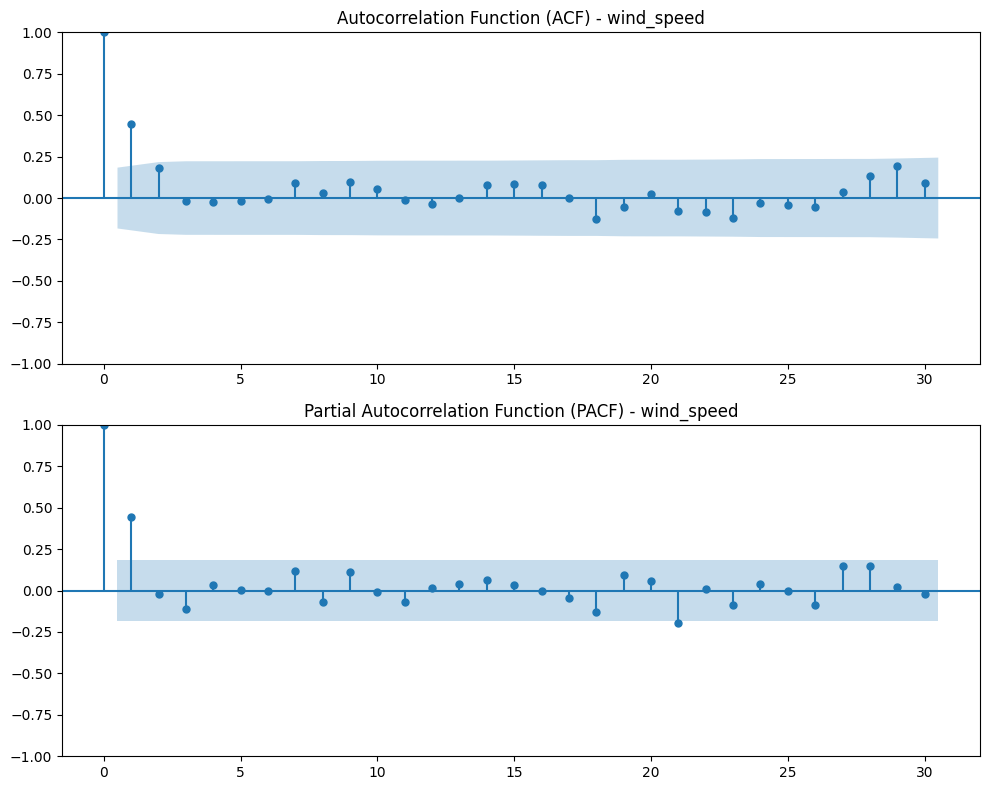

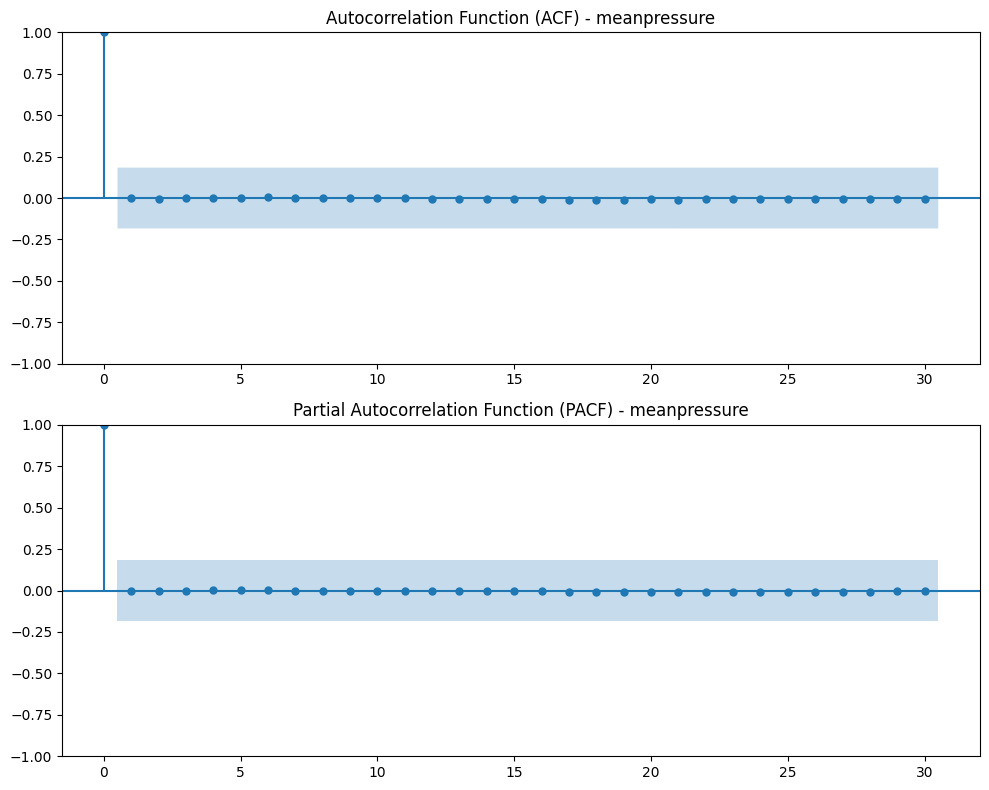

In [16]:
for col in df.columns:
    fig, axs = plt.subplots(2, 1, figsize=(10, 8))
    
    # ACF plot
    plot_acf(df[col].dropna(), lags=30, ax=axs[0])
    axs[0].set_title(f"Autocorrelation Function (ACF) - {col}")
    
    # PACF plot
    plot_pacf(df[col].dropna(), lags=30, ax=axs[1], method='ywm')
    axs[1].set_title(f"Partial Autocorrelation Function (PACF) - {col}")
    
    plt.tight_layout()
    plt.show()

For all the variables, the ACF plots show significant spikes at the initial lags (often starting at lag 1) that remain above the confidence bounds. This means that current values are highly correlated with their past values, which is consistent with the very low Durbin-Watson statistics we observed.

If the ACF plots display a slow decay (rather than cutting off abruptly), it is often a sign of non-stationarity.

The combination of very low Durbin-Watson values and significant ACF/PACF spikes strongly indicates that the series are not only correlated but that the correlation is both strong and persistent over time.

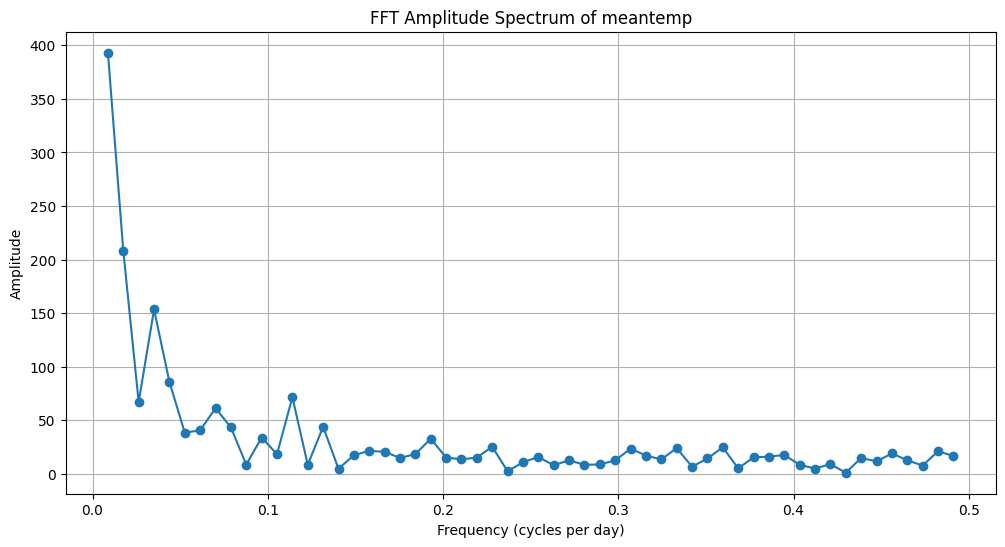

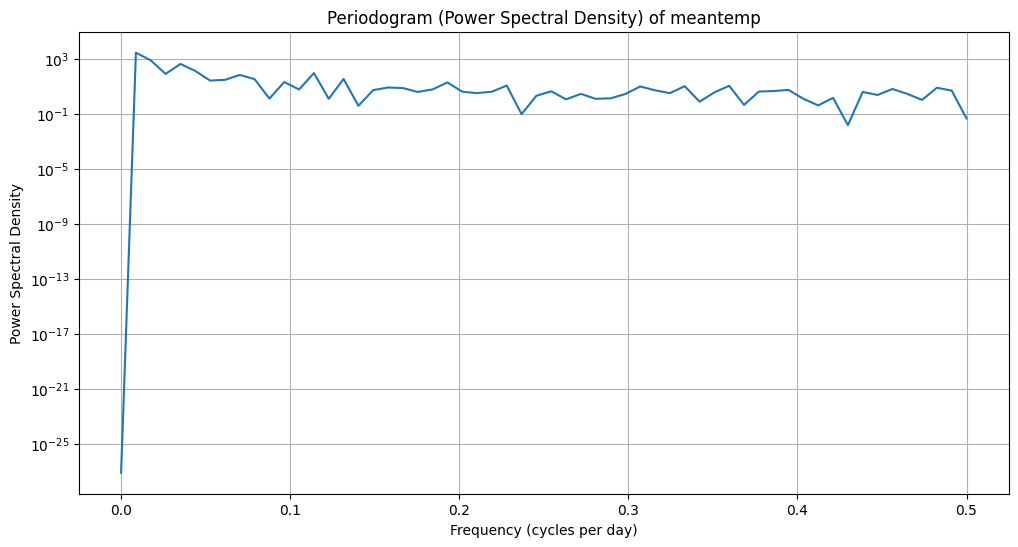

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import periodogram

# Ensuring there are no missing values)
signal = df['meantemp'].dropna().values

# Define sampling frequency: 1 sample per day
fs = 1  

# ---- FFT Approach ----
N = len(signal)
fft_values = np.fft.fft(signal)
frequencies = np.fft.fftfreq(N, d=1/fs)

# Only consider positive frequencies for plotting
positive_idx = frequencies > 0
fft_magnitude = np.abs(fft_values[positive_idx])
freq_positive = frequencies[positive_idx]

plt.figure(figsize=(12, 6))
plt.plot(freq_positive, fft_magnitude, marker='o', linestyle='-')
plt.title("FFT Amplitude Spectrum of meantemp")
plt.xlabel("Frequency (cycles per day)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

# ---- Periodogram Approach ----
f, Pxx_den = periodogram(signal, fs=fs)

plt.figure(figsize=(12, 6))
plt.semilogy(f, Pxx_den)  # semilogy for better visualization of PSD values
plt.title("Periodogram (Power Spectral Density) of meantemp")
plt.xlabel("Frequency (cycles per day)")
plt.ylabel("Power Spectral Density")
plt.grid(True)
plt.show()

c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:               meantemp   No. Observations:                   84
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -166.637
Date:                Sun, 06 Apr 2025   AIC                            345.274
Time:                        11:23:27   BIC                            359.859
Sample:                    01-01-2017   HQIC                           351.137
                         - 03-25-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         18.9489      2.059      9.202      0.000      14.913      22.985
ar.L1          1.0277      1.443      0.712      0.476      -1.801       3.856
ar.L2         -0.1267      1.322

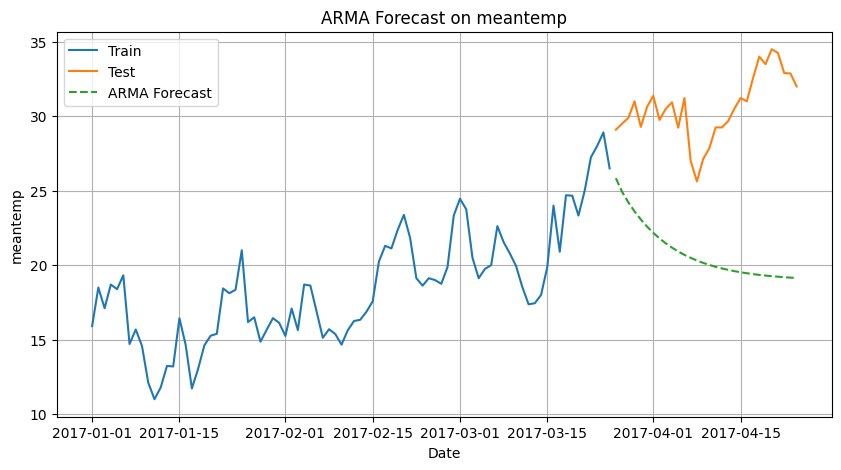

c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Paul\AppD

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:               meantemp   No. Observations:                   84
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -164.197
Date:                Sun, 06 Apr 2025   AIC                            338.395
Time:                        11:23:27   BIC                            350.489
Sample:                    01-01-2017   HQIC                           343.253
                         - 03-25-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0602      0.843     -0.071      0.943      -1.712       1.591
ar.L2          0.6731      0.609      1.105      0.269      -0.521       1.867
ma.L1         -0.0851      0.85

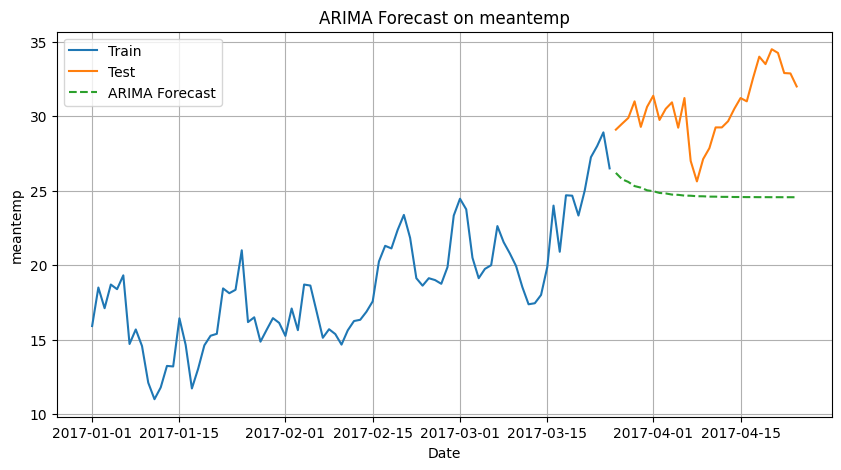

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

# Assuming df is already loaded with the "meantemp" column
# Split the data: use all but the last 30 data points for training, and the last 30 for testing
train = df['meantemp'][:-30]
test = df['meantemp'][-30:]

### ARMA Model (ARIMA with d=0) ###
# We try an ARMA model with order (2, 0, 2)
arma_order = (2, 0, 2)
model_arma = ARIMA(train, order=arma_order)
arma_fit = model_arma.fit()
print("ARMA Model Summary:")
print(arma_fit.summary())

# Forecast for the test period (30 days)
forecast_arma = arma_fit.forecast(steps=30)

# Evaluate performance using RMSE
rmse_arma = np.sqrt(mean_squared_error(test, forecast_arma))
print("ARMA (order 2,0,2) RMSE:", rmse_arma)

# Plot ARMA forecast vs actual data
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast_arma, label="ARMA Forecast", linestyle='--')
plt.title("ARMA Forecast on meantemp")
plt.xlabel("Date")
plt.ylabel("meantemp")
plt.legend()
plt.grid(True)
plt.show()

### ARIMA Model ###
# Since meantemp might be non-stationary (as suggested by the ADF test),
# we fit an ARIMA model with one differencing step, for example order (2,1,2)
arima_order = (2, 1, 2)
model_arima = ARIMA(train, order=arima_order)
arima_fit = model_arima.fit()
print("ARIMA Model Summary:")
print(arima_fit.summary())

# Forecast for the test period (30 days)
forecast_arima = arima_fit.forecast(steps=30)

# Evaluate performance using RMSE
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
print("ARIMA (order 2,1,2) RMSE:", rmse_arima)

# Plot ARIMA forecast vs actual data
plt.figure(figsize=(10,5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast_arima, label="ARIMA Forecast", linestyle='--')
plt.title("ARIMA Forecast on meantemp")
plt.xlabel("Date")
plt.ylabel("meantemp")
plt.legend()
plt.grid(True)
plt.show()


c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:             wind_speed   No. Observations:                   84
Model:                 ARIMA(2, 0, 2)   Log Likelihood                -208.002
Date:                Sun, 06 Apr 2025   AIC                            428.004
Time:                        11:26:01   BIC                            442.588
Sample:                    01-01-2017   HQIC                           433.867
                         - 03-25-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.6103      0.400     19.007      0.000       6.826       8.395
ar.L1          1.1940      0.132      9.040      0.000       0.935       1.453
ar.L2         -0.8406      0.125

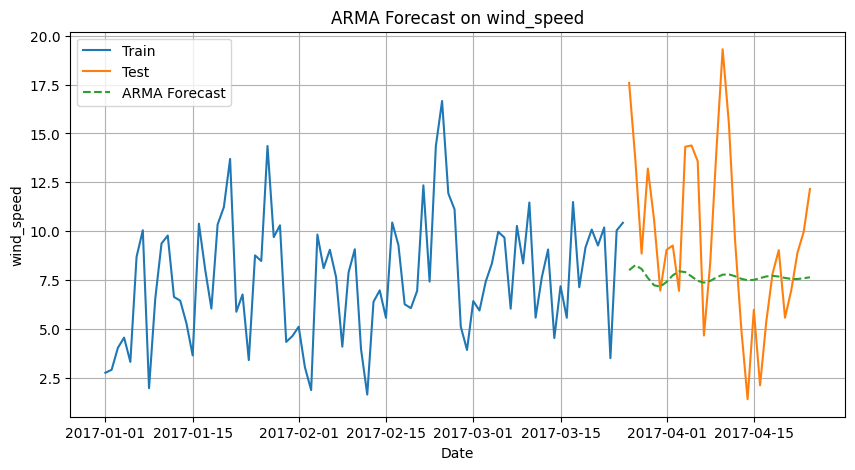

c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\Paul\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Paul\AppD

ARIMA Model Summary:
                               SARIMAX Results                                
Dep. Variable:             wind_speed   No. Observations:                   84
Model:                 ARIMA(2, 1, 2)   Log Likelihood                -208.770
Date:                Sun, 06 Apr 2025   AIC                            427.540
Time:                        11:26:01   BIC                            439.634
Sample:                    01-01-2017   HQIC                           432.399
                         - 03-25-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0873      1.587     -0.055      0.956      -3.197       3.022
ar.L2          0.1914      0.484      0.395      0.693      -0.758       1.140
ma.L1         -0.5656      1.62

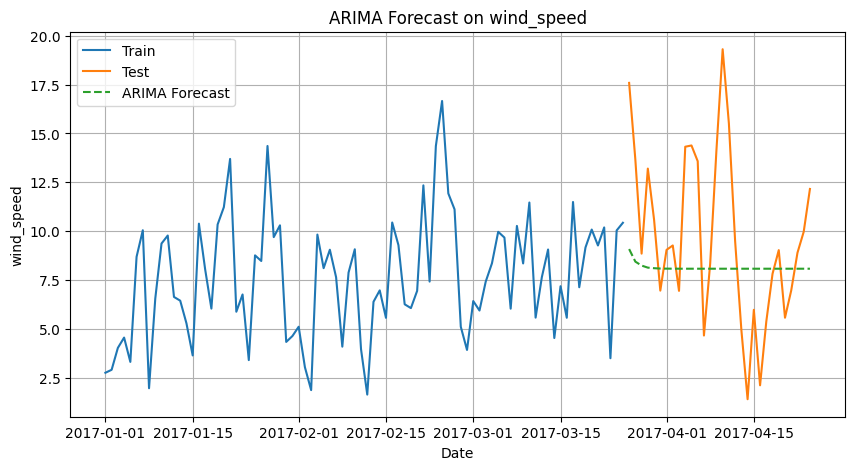

In [20]:
# Use wind_speed for forecasting 
train = df['wind_speed'][:-30]
test = df['wind_speed'][-30:]

### ARMA Model (ARIMA with d=0)
# For a stationary series, ARMA (i.e. ARIMA with d=0) is appropriate.
arma_order = (2, 0, 2)
model_arma = ARIMA(train, order=arma_order)
arma_fit = model_arma.fit()
print("ARMA Model Summary:")
print(arma_fit.summary())

# Forecast the next 30 data points using the ARMA model
forecast_arma = arma_fit.forecast(steps=30)

# Evaluate performance using RMSE
rmse_arma = np.sqrt(mean_squared_error(test, forecast_arma))
print("ARMA (order 2,0,2) RMSE:", rmse_arma)

# Plot ARMA forecast vs. actual data
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast_arma, label="ARMA Forecast", linestyle='--')
plt.title("ARMA Forecast on wind_speed")
plt.xlabel("Date")
plt.ylabel("wind_speed")
plt.legend()
plt.grid(True)
plt.show()

### ARIMA Model
# Even though wind_speed is stationary, we can experiment with a model that includes differencing.
# Here we try an ARIMA with one differencing step: order (2, 1, 2).
arima_order = (2, 1, 2)
model_arima = ARIMA(train, order=arima_order)
arima_fit = model_arima.fit()
print("ARIMA Model Summary:")
print(arima_fit.summary())

# Forecast the next 30 data points using the ARIMA model
forecast_arima = arima_fit.forecast(steps=30)

# Evaluate performance using RMSE
rmse_arima = np.sqrt(mean_squared_error(test, forecast_arima))
print("ARIMA (order 2,1,2) RMSE:", rmse_arima)

# Plot ARIMA forecast vs. actual data
plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast_arima, label="ARIMA Forecast", linestyle='--')
plt.title("ARIMA Forecast on wind_speed")
plt.xlabel("Date")
plt.ylabel("wind_speed")
plt.legend()
plt.grid(True)
plt.show()


The current model for forecasting Wind Speed appears to underfit the data. The forecast remains relatively flat around 7–8 m/s, failing to capture the higher variability and spikes seen in the test period.

Testing ARMA configurations for wind_speed:

Order (0, 0, 1) -> RMSE: 3.4697
Order (0, 0, 2) -> RMSE: 3.4649
Order (0, 0, 3) -> RMSE: 3.4796
Order (0, 0, 4) -> RMSE: 3.5524
Order (1, 0, 0) -> RMSE: 3.4650
Order (1, 0, 1) -> RMSE: 3.4651
Order (1, 0, 2) -> RMSE: 3.4692
Order (1, 0, 3) -> RMSE: 3.5259
Order (1, 0, 4) -> RMSE: 3.5370
Order (2, 0, 0) -> RMSE: 3.4651
Order (2, 0, 1) -> RMSE: 3.4993
Order (2, 0, 2) -> RMSE: 3.5213
Order (2, 0, 3) -> RMSE: 3.4344
Order (2, 0, 4) -> RMSE: 3.5052
Order (3, 0, 0) -> RMSE: 3.4571
Order (3, 0, 1) -> RMSE: 3.4799
Order (3, 0, 2) -> RMSE: 3.5193
Order (3, 0, 3) -> RMSE: 3.5123
Order (3, 0, 4) -> RMSE: 3.5082
Order (4, 0, 0) -> RMSE: 3.5014
Order (4, 0, 1) -> RMSE: 3.4832
Order (4, 0, 2) -> RMSE: 3.5528
Order (4, 0, 3) -> RMSE: 3.5508
Order (4, 0, 4) -> RMSE: 3.5129

Best ARMA order: (2, 0, 3) with RMSE: 3.434350474281942


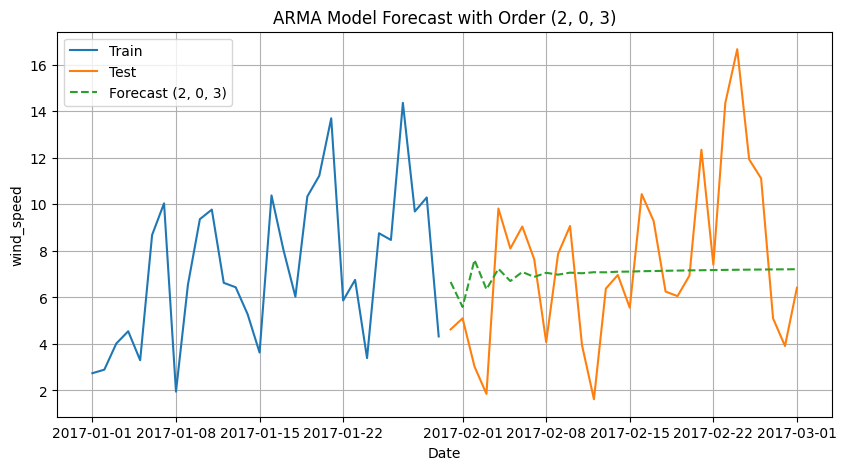

In [33]:
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# Use wind_speed for forecasting
window = 30
train = df['wind_speed'][:window]
test = df['wind_speed'][window:window*2]

# Define grid search ranges for AR (p) and MA (q) orders
p_values = range(0, 5)
q_values = range(0, 5)

results = []
best_rmse = np.inf
best_order = None

print("Testing ARMA configurations for wind_speed:\n")
for p in p_values:
    for q in q_values:
        # Skip the trivial model (0,0,0)
        if p == 0 and q == 0:
            continue
        try:
            order = (p, 0, q)
            model = ARIMA(train, order=order)
            model_fit = model.fit()
            forecast = model_fit.forecast(steps=window)
            rmse = np.sqrt(mean_squared_error(test, forecast))
            results.append((order, rmse))
            print(f"Order {order} -> RMSE: {rmse:.4f}")
            
            # Track the best configuration
            if rmse < best_rmse:
                best_rmse = rmse
                best_order = order
        except Exception as e:
            print(f"Order {(p, 0, q)} failed: {e}")

print("\nBest ARMA order:", best_order, "with RMSE:", best_rmse)

best_model = ARIMA(train, order=best_order)
best_model_fit = best_model.fit()
forecast_best = best_model_fit.forecast(steps=window)

plt.figure(figsize=(10, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast_best, label=f"Forecast {best_order}", linestyle='--')
plt.title(f"ARMA Model Forecast with Order {best_order}")
plt.xlabel("Date")
plt.ylabel("wind_speed")
plt.legend()
plt.grid(True)
plt.show()


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        9.421       9.515   1.235e+04       9.458
1        7.049      7.423*       1152.       7.198
2       6.880*       7.534      974.5*      7.141*
3        7.013       7.947       1117.       7.386
4        7.170       8.384       1314.       7.655
5        7.300       8.795       1512.       7.896
6        7.464       9.239       1807.       8.172
7        7.491       9.546       1894.       8.310
8        7.642       9.977       2263.       8.573
9        7.715       10.33       2524.       8.758
10       7.823       10.72       2944.       8.978
--------------------------------------------------
Selected lag order (AIC): 2
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sun, 06, Apr, 2025
Time:                     11:46:51
--------------------------------

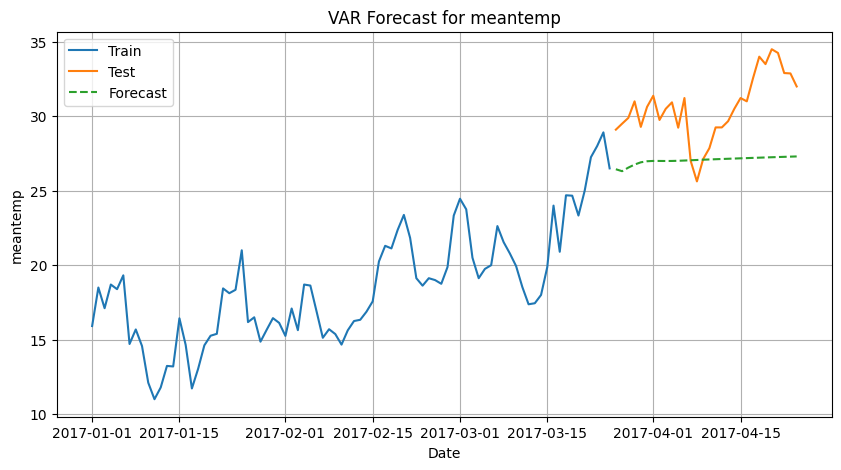

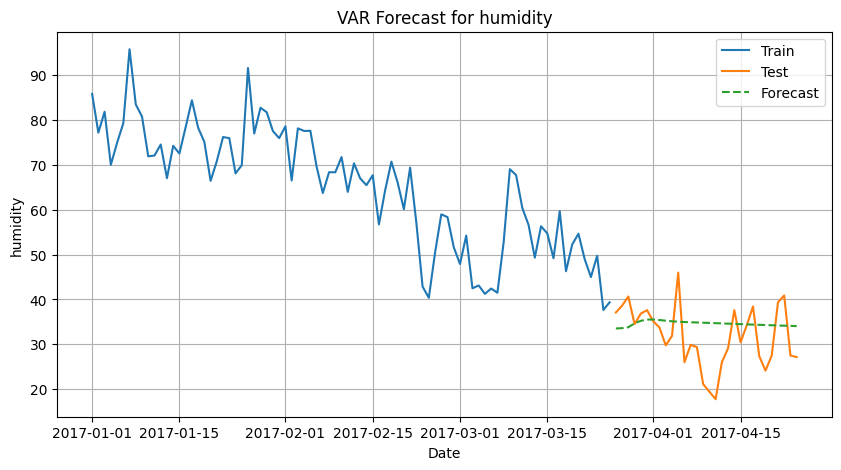

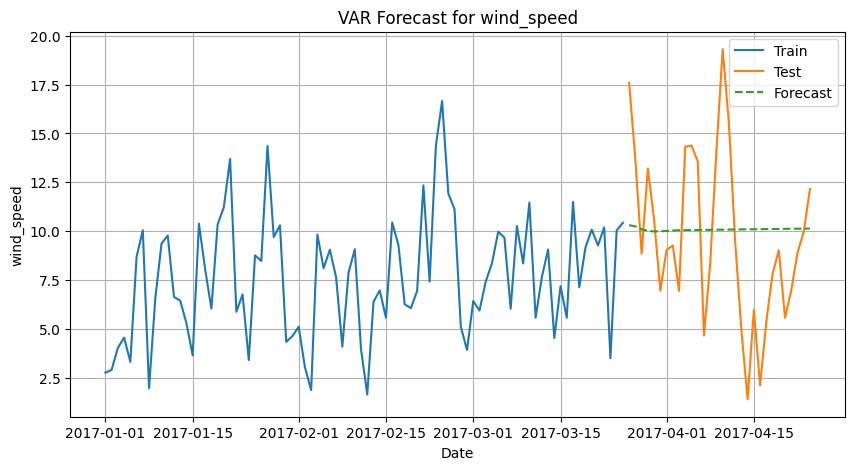

In [ ]:
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
import pandas as pd

df_mult = df[['meantemp', 'humidity', 'wind_speed']].copy()
train_mult = df_mult[:-30]
test_mult = df_mult[-30:]

model_var = VAR(train_mult)
lag_order_results = model_var.select_order(maxlags=10)
print(lag_order_results.summary())

selected_lag = 5
print("Selected lag order (manual override):", selected_lag)

var_model = model_var.fit(selected_lag)
print(var_model.summary())

forecast_values = var_model.forecast(train_mult.values, steps=30)
forecast_df = pd.DataFrame(forecast_values, index=test_mult.index, columns=train_mult.columns)
print(forecast_df)

for col in train_mult.columns:
    plt.figure(figsize=(10, 5))
    plt.plot(train_mult.index, train_mult[col], label="Train")
    plt.plot(test_mult.index, test_mult[col], label="Test")
    plt.plot(forecast_df.index, forecast_df[col], label="Forecast", linestyle='--')
    plt.title(f"VAR Forecast for {col}")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.show()
